###Intro:

The goal of this project is to develop a deep learning model that can accurately classify facial expressions into one of seven categories: Angry, Disgust, Fear, Happy, Sad, Surprise, and Neutral. We will use convolutional neural networks (CNNs) to train our model, as they have been shown to be effective in image classification tasks. Our approach involves training a CNN model from scratch on the FER-2013 dataset



###data:

The FER-2013 dataset consists of 48x48 pixel grayscale images of faces that have been automatically registered to be centred and occupy a similar amount of space in each image. The dataset contains 24,400 images, with 22,968 examples in the training set and 1,432 examples in the public test set.

## 1-import the libraries important to work

In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization, Input,ZeroPadding2D
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import regularizers
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


## 2 -- Loading data

The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centered and occupies about the same amount of space in each image. The task is to categorize each face based on the emotion shown in the facial expression in to one of seven categories:

emotion_labels = {
    'Anger': 0,
    'Disgust': 1,
    'Fear': 2,
    'Happy': 3,
    'Sad': 4,
    'Surprise': 5,
    'Neutral': 6
}

In [ ]:
!pip install gdown
import gdown

In [ ]:
import os
import gdown

# Use an environment variable or a clean placeholder instead of your raw ID
# You can set GOOGLE_DRIVE_FILE_ID in your environment, or paste a placeholder here
file_id = os.getenv("GOOGLE_DRIVE_FILE_ID", "YOUR_GOOGLE_DRIVE_FILE_ID_HERE")

if file_id != "YOUR_GOOGLE_DRIVE_FILE_ID_HERE":
    url = f"https://drive.google.com/uc?id={file_id}"
    output = "data.csv"

    # Download the file
    gdown.download(url, output, quiet=False)
else:
    print("Skipping download: No valid file ID provided.")

In [ ]:
data = pd.read_csv("data.csv")

## 3-- Data Exploration :

### a-- Summary statistics

In [ ]:
emotion_mapping = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

count_emotions = (data.groupby(data['emotion'])['pixels'].count()).to_frame()
count_emotions['emotion name'] = [emotion_mapping[k] for k in emotion_mapping.keys()]
count_emotions

,pixels,emotion name
emotion,,
0,4953,Angry
1,547,Disgust
2,5121,Fear
3,8989,Happy
4,6077,Sad
5,4002,Surprise
6,6198,Neutral


In [ ]:
#number of row and coloumn
data.shape

(35887, 3)

In [ ]:
# Get basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   pixels   35887 non-null  object
 2   Usage    35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


In [ ]:
#get mean and min and max...
data.describe()

,emotion
count,35887.000000
mean,3.323265
std,1.873819
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


In [ ]:

emotion_mapping = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

# Count the occurrences of each emotion
emotion_counts = data['emotion'].value_counts()

# Map the numeric labels to emotion names
emotion_counts_named = emotion_counts.rename(emotion_mapping)

# Display the result
print(emotion_counts_named)


emotion
Happy       8989
Neutral     6198
Sad         6077
Fear        5121
Angry       4953
Surprise    4002
Disgust      547
Name: count, dtype: int64


In [ ]:
data['Usage'].value_counts()

,count
Usage,
Training,28709
PublicTest,3589
PrivateTest,3589


### b-- Data visualization

In [ ]:
data.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [ ]:
import plotly.express as px
import pandas as pd

# Load your dataset
data_plot = pd.read_csv("data.csv")

# Define the class labels and a mapping
CLASS_LABELS1 = ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', 'Surprise']
emotion_map = {i: label for i, label in enumerate(CLASS_LABELS1)}

# Map numeric emotion values to class labels
data_plot['emotion_labels'] = data_plot['emotion'].map(emotion_map)

# Count the occurrences of each emotion (unordered)
emotion_counts = data_plot['emotion_labels'].value_counts()

# Shuffle the order of labels randomly (or use a specific order you want)
emotion_counts = emotion_counts.sample(frac=1)  # `frac=1` shuffles the rows

# Create the bar chart
fig1 = px.bar(
    x=emotion_counts.index,
    y=emotion_counts.values,
    color=emotion_counts.index,
    color_continuous_scale="Emrld"
)

# Update axes titles and layout
fig1.update_xaxes(title="Emotions")
fig1.update_yaxes(title="Number of Images")
fig1.update_layout(
    showlegend=AC,
    title={
        'text': 'Data Distribution',
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }
)

# Show the figure
fig1.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Assuming you have already loaded the data_plotset into a data_plotFrame 'data'
# Example data structure

# Load your dataset
data_plot3 = pd.read_csv("data.csv")

# Grouping by 'Usage' and 'emotion' and counting occurrences
usage_emotion_counts = data_plot3.groupby(['Usage', 'emotion']).size().reset_index(name='count')

# Mapping emotion indices to emotion names and emojis
CLASS_LABELS = ['Anger 😡', 'Disgust 🤢', 'Fear 😨', 'Happy 😊', 'Neutral 😐', 'Sadness 😢', 'Surprise 😲']
usage_emotion_counts['emotion_label'] = usage_emotion_counts['emotion'].map(lambda x: CLASS_LABELS[x])

# Plot the data_plot using Plotly
fig3 = px.bar(usage_emotion_counts,
             x='emotion_label', y='count',
             color='Usage',
             title='Emotion Distribution Across Different Usage Types',
             labels={'emotion_label': 'Emotion', 'count': 'Number of Images', 'Usage': 'Usage Type'},
             barmode='stack')

# Customize layout
fig3.update_layout(
    xaxis_title="Emotion",
    yaxis_title="Number of Images",
    showlegend=True,
    title={'text': 'Emotion Distribution in Training, PublicTest, and PrivateTest', 'x': 0.5, 'xanchor': 'center'}
)

# Show the plot
fig3.show()


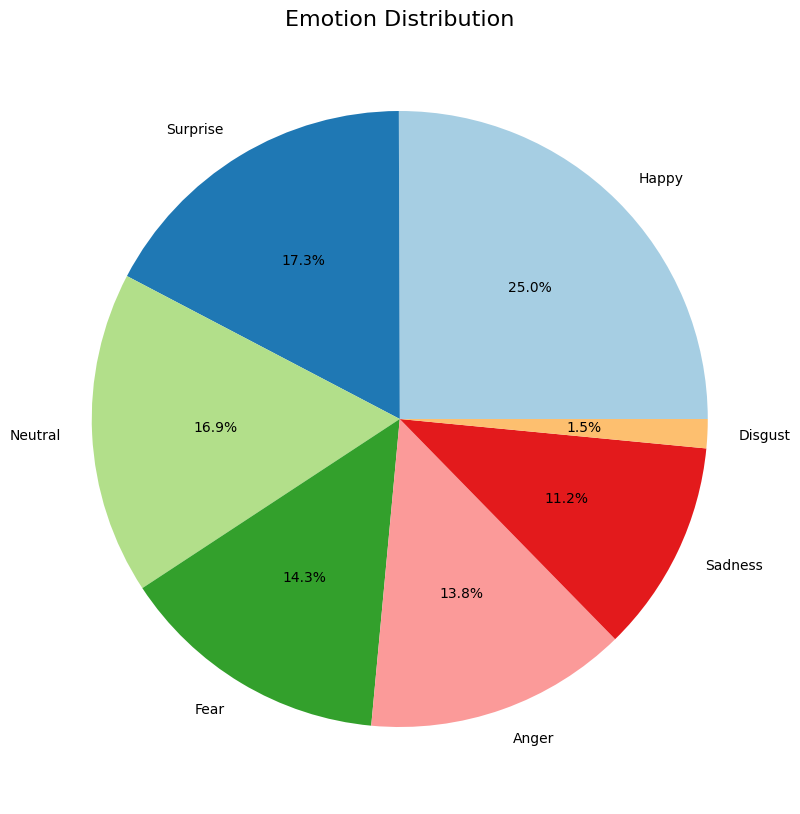

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data_pl = pd.read_csv("data.csv")
# Define the CLASS_LABELS
CLASS_LABELS = ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', 'Surprise']

# Replace the emotion column with the CLASS_LABELS (if it's a numeric code or map to the appropriate class)
# Ensure that your 'emotion' column contains the correct values corresponding to the emotion classes.
# If 'emotion' is already categorical or string type, you may not need this step.
# Assuming data['emotion'] is an index or numeric code, we can map them as follows:

# Create a dictionary to map numerical values to emotion labels
emotion_map = {i: label for i, label in enumerate(CLASS_LABELS)}

# If 'data['emotion']' contains numerical values (e.g., 0, 1, 2, 3, ...), we can map them to the labels
data_pl['emotion'] = data_pl['emotion'].map(emotion_map)

# Now, plot the pie chart
country_counts = data_pl['emotion'].value_counts()

# Plot
plt.figure(figsize=(12, 10))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', colors=plt.cm.Paired(np.arange(len(country_counts))))
plt.title('Emotion Distribution', fontsize=16)
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px



# Count the number of occurrences for each label in the 'Usage' column
usage_counts = data['Usage'].value_counts().reset_index()
usage_counts.columns = ['Usage', 'Count']

# Create a bar chart using Plotly
fig = px.bar(usage_counts, x='Usage', y='Count', title="Distribution of Labels in Usage Column", color='Usage')

# Update axes titles and layout
fig.update_xaxes(title="Usage Type")
fig.update_yaxes(title="Number of Instances")
fig.update_layout(showlegend=False)

# Show the plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load your data_plot2set
data_plot2 = pd.read_csv("data.csv")

# Define the class labels and create a mapping
CLASS_LABELS = ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', 'Surprise']
emotion_map = {i: label for i, label in enumerate(CLASS_LABELS)}

# Map numeric emotion values to class labels
data_plot2['emotion_labels'] = data_plot2['emotion'].map(emotion_map)

# Group by 'Usage' and count occurrences of each 'emotion_labels' within each usage category
usage_emotion_counts = data_plot2.groupby(['Usage', 'emotion_labels']).size().unstack(fill_value=0)

# Reset the index to have 'Usage' as a column
usage_emotion_counts = usage_emotion_counts.reset_index()

# Plot the result using Plotly for better visualization
fig = px.bar(
    usage_emotion_counts,
    x='Usage',
    y=usage_emotion_counts.columns[1:],  # All columns except the first one (Usage)
    title="Number of Each Emotion Label in Different Usage Categories",
    labels={'value': 'Number of Images', 'emotion_labels': 'Emotion'},
    barmode='stack'
)

# Update layout for better readability
fig.update_layout(
    xaxis_title="Usage Type",
    yaxis_title="Number of Instances",
    legend_title="Emotion Label"
)

# Show the plot
fig.show()


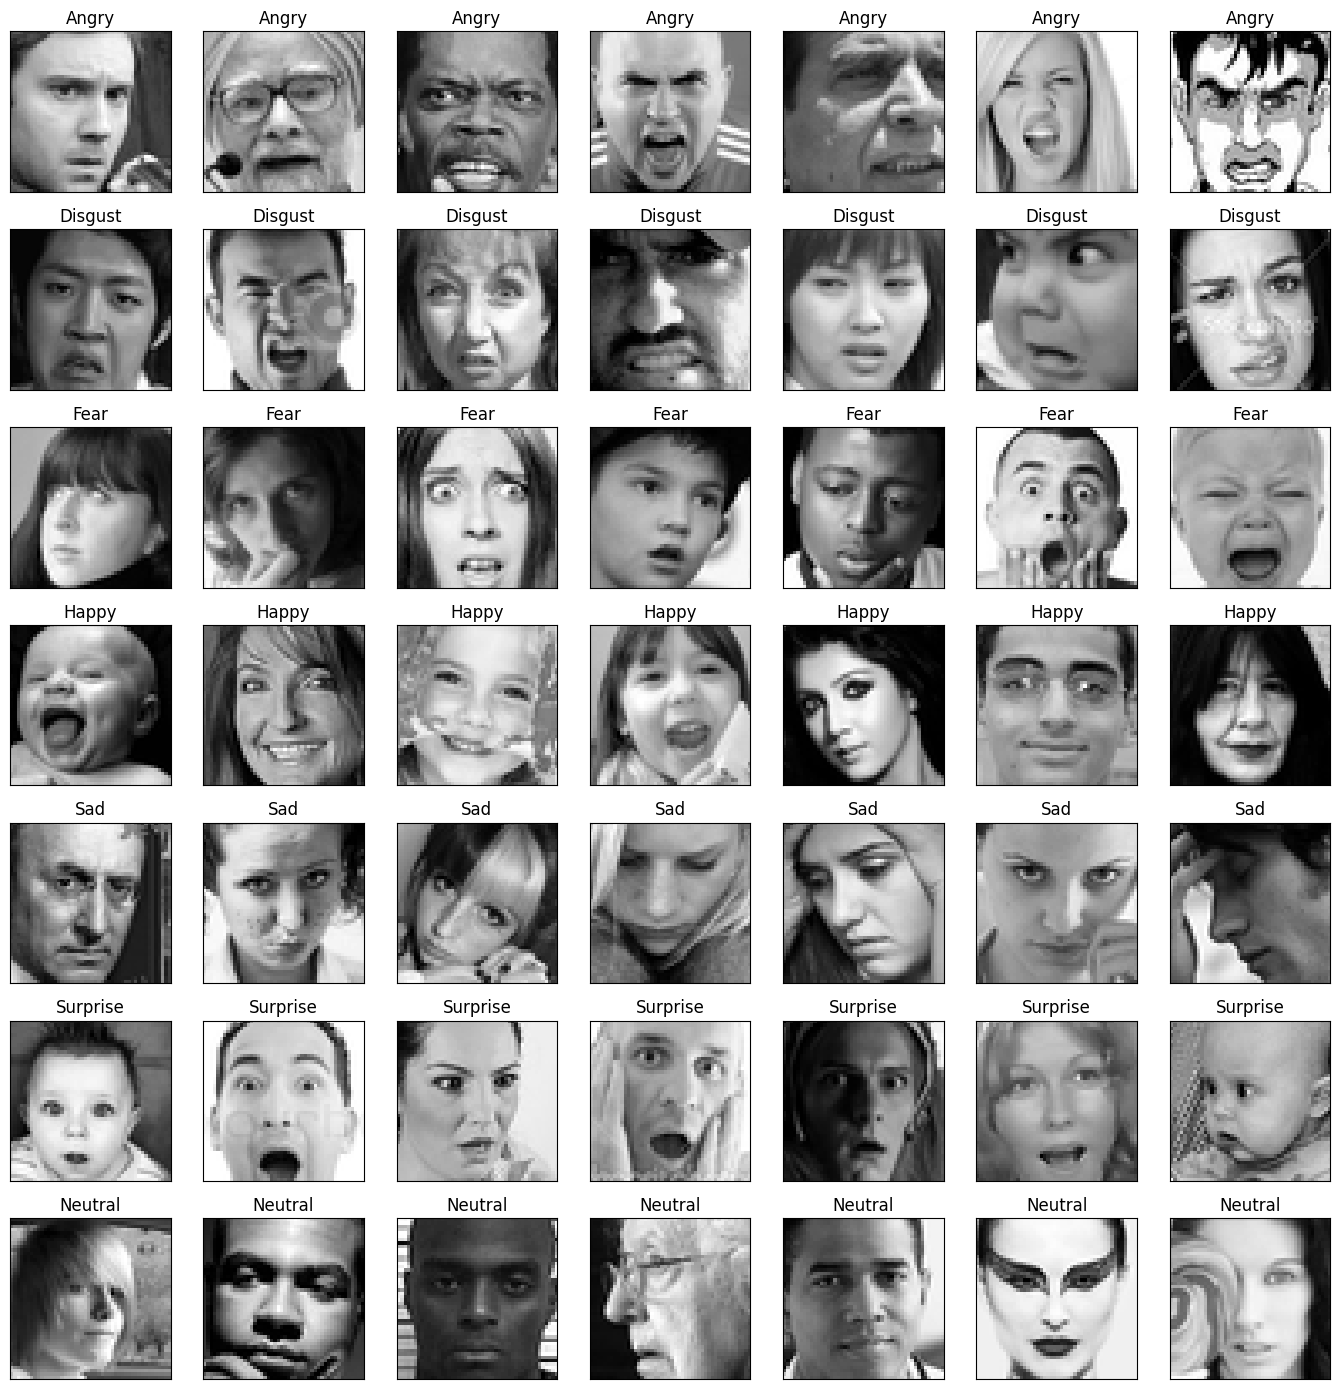

In [ ]:
from matplotlib import pyplot
fig = pyplot.figure(1, (14, 14))

k = 0
for label in sorted(data.emotion.unique()):
    for j in range(7):
        px = data[data.emotion==label].pixels.iloc[k]
        px = np.array(px.split(' ')).reshape(48, 48).astype('float32')

        k += 1
        ax = pyplot.subplot(7, 7, k)
        ax.imshow(px, cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(emotion_mapping[label])
        pyplot.tight_layout()

## 4 -- Data preprocessing

In this section, we will be using both data generators and data augmentation to train a deep learning model for human emotion detection using the FER-2013 dataset. Due to the size and complexity of the dataset, it would be impractical to load all of the images into memory at once. Therefore, we will be using data generators to generate batches of images on-the-fly during training, which will allow us to efficiently train our model on the entire dataset.

In addition, we will be applying various data augmentation techniques to the training images, such as rotation, shifting, and flipping. This will help to increase the size and diversity of our training set, which can improve the performance of our deep learning model. By introducing variability into the training process, data augmentation can also help to prevent overfitting, which occurs when the model becomes too closely tailored to the training set and performs poorly on new, unseen data.

### a-Handling Missing Data

In [ ]:
#checking missing values
data.isnull().sum()

,0
emotion,0
pixels,0
Usage,0


<Axes: >

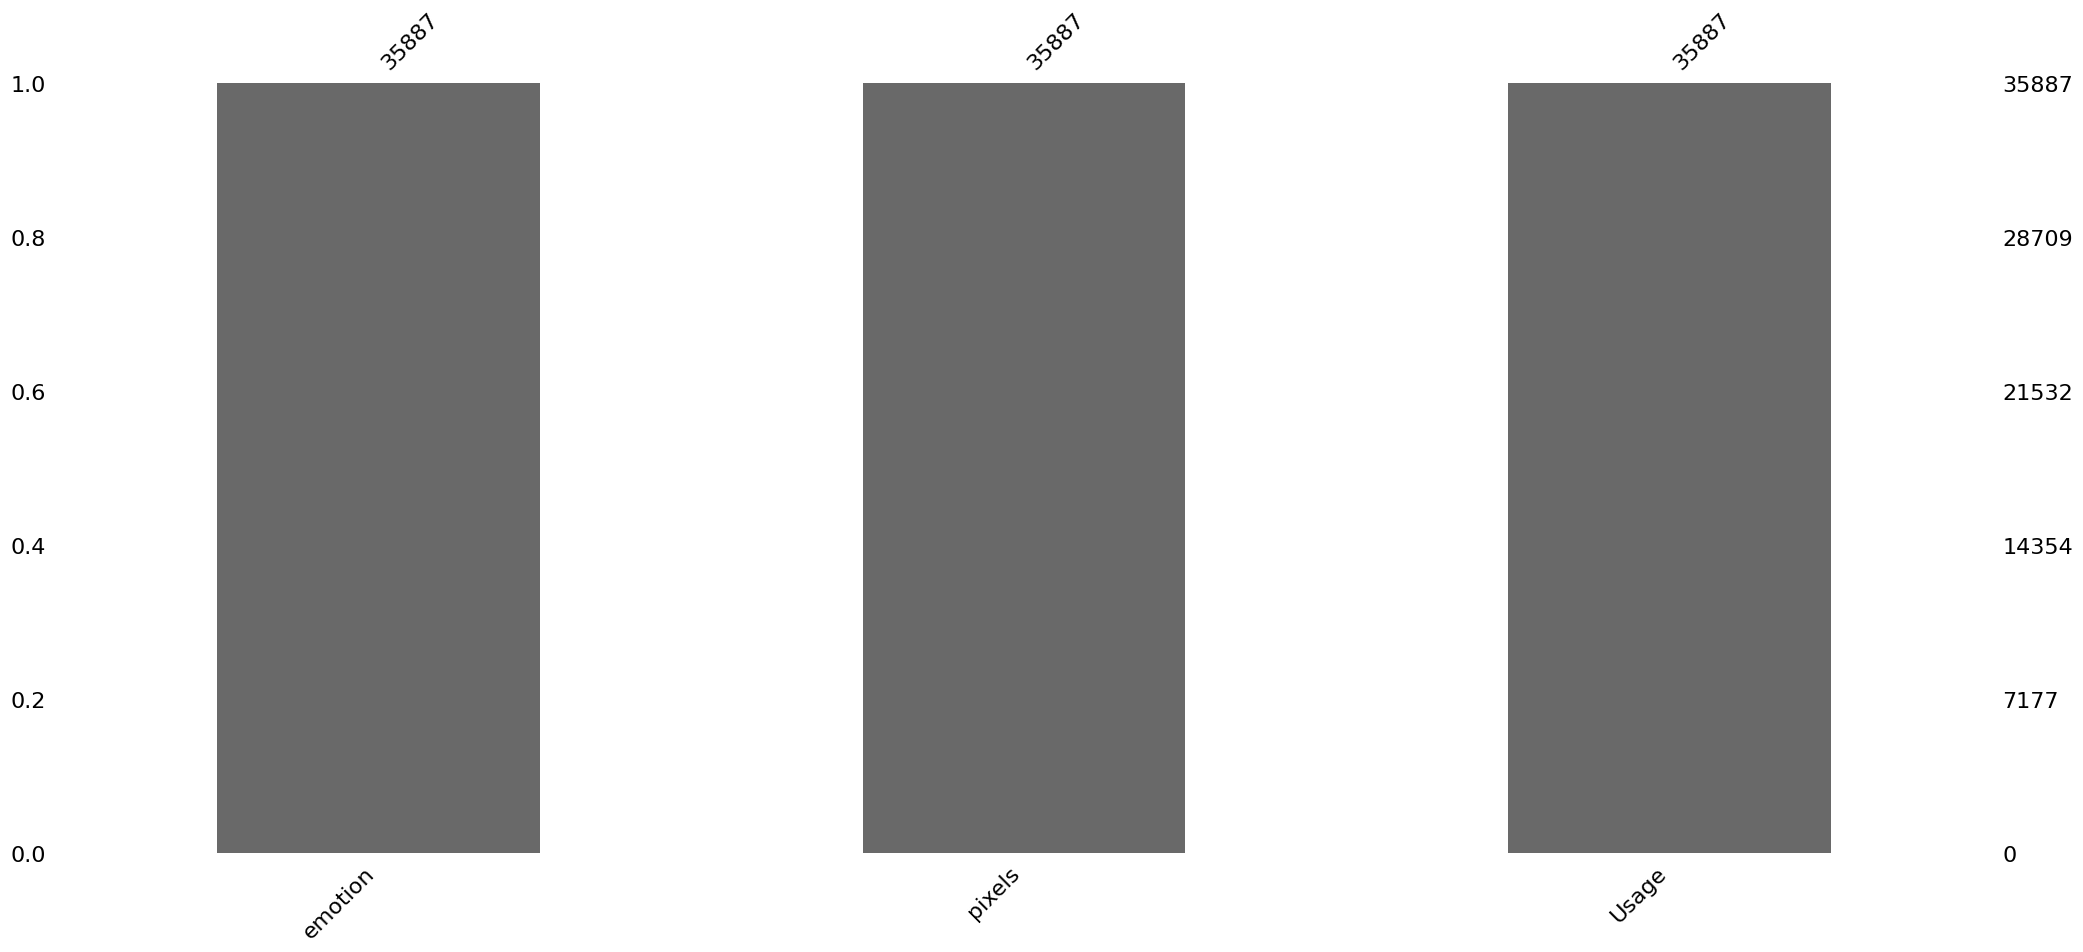

In [ ]:
import missingno as msno
msno.bar(data)

### b-Split the Data Based on the Usage Column

In [ ]:
# Split the dataset into training, validation, and testing based on the 'Usage' column
train_data = data[data['Usage'] == 'Training']
val_data = data[data['Usage'] == 'PublicTest']  # Or 'PrivateTest' based on your need
test_data = data[data['Usage'] == 'PrivateTest']  # If you have a separate validation set

# Check the split
print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")
print(f"Validation data shape: {val_data.shape}")

Training data shape: (28709, 3)
Testing data shape: (3589, 3)
Validation data shape: (3589, 3)


### c- Convert Image Pixels to NumPy Arrays

In [ ]:
# Convert the 'pixels' column into NumPy arrays
def convert_pixels(dataset):
    return np.array(list(map(str.split, dataset['pixels'])), dtype=np.float32)

train_data_arr = convert_pixels(train_data)
val_data_arr = convert_pixels(val_data)
test_data_arr = convert_pixels(test_data)

print("Shape of raw pixel arrays:")
print("X_train:",train_data_arr.shape)
print("X_val:", val_data_arr.shape)
print("X_test:", test_data_arr.shape)

Shape of raw pixel arrays:
X_train: (28709, 2304)
X_val: (3589, 2304)
X_test: (3589, 2304)


### d-Process the Labels

In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert emotion labels to one-hot encoding
y_train = to_categorical(train_data['emotion'], num_classes=7)
y_val = to_categorical(val_data['emotion'], num_classes=7)
y_test = to_categorical(test_data['emotion'], num_classes=7)

print("One-hot encoded labels:")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

One-hot encoded labels:
y_train: (28709, 7)
y_val: (3589, 7)
y_test: (3589, 7)


### e. Normalizing the Pixel Values

Normalize the pixel values so that they range from 0 to 1 (instead of 0 to 255). This is important for neural networks as it helps with convergence during training.

In [ ]:
# Check the range of pixel values before normalization
print(f"Pixel value range before normalization:")
print(f"Train data - min: {train_data_arr.min()}, max: {train_data_arr.max()}")
print(f"Validation data - min: {val_data_arr.min()}, max: {val_data_arr.max()}")
print(f"Test data - min: {test_data_arr.min()}, max: {test_data_arr.max()}")

Pixel value range before normalization:
Train data - min: 0.0, max: 255.0
Validation data - min: 0.0, max: 255.0
Test data - min: 0.0, max: 255.0


In [ ]:
# Normalize pixel values to the range 0-1
train_data_arr /= 255.0
val_data_arr /= 255.0
test_data_arr /= 255.0

# Check the range of pixel values after normalization
print(f"Pixel value range after normalization:")
print(f"Train data - min: {train_data_arr.min()}, max: {train_data_arr.max()}")
print(f"Validation data - min: {val_data_arr.min()}, max: {val_data_arr.max()}")
print(f"Test data - min: {test_data_arr.min()}, max: {test_data_arr.max()}")


Pixel value range after normalization:
Train data - min: 0.0, max: 1.0
Validation data - min: 0.0, max: 1.0
Test data - min: 0.0, max: 1.0


### f-reshape for CNN Input

In [ ]:
# Reshape the arrays to (samples, 48, 48, 1)
x_train_reshape = train_data_arr.reshape(-1, 48, 48, 1)
x_val_reshape = val_data_arr.reshape(-1, 48, 48, 1)
x_test_reshape = test_data_arr.reshape(-1, 48, 48, 1)

print("Reshaped arrays:")
print("X_train:", x_train_reshape.shape)
print("X_val:", x_val_reshape.shape)
print("X_test:", x_test_reshape.shape)

Reshaped arrays:
X_train: (28709, 48, 48, 1)
X_val: (3589, 48, 48, 1)
X_test: (3589, 48, 48, 1)


### g. Data Augmentation

We can do data augmentation to have more data to train and validate our model to prevent overfitting. Data augmentation can be done on training and validation sets as it helps the model become more generalize and robust

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from matplotlib import pyplot as plt

# Class labels for emotions
CLASS_LABELS = ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', 'Surprise']

# Setup for data augmentation
datagen_train = ImageDataGenerator(
    rotation_range=10,  # Rotate the images slightly
    horizontal_flip=True,  # Flip images horizontally
    width_shift_range=0.1,  # Shift images horizontally
    height_shift_range=0.1,  # Shift images vertically
    fill_mode='nearest',  # Fill pixels when shifting
    zoom_range = 0.2      # Random zoom
)


datagen_val  = ImageDataGenerator(   width_shift_range = 0.1,
                               height_shift_range = 0.1,
                               horizontal_flip = True,
                               zoom_range = 0.2)

In [ ]:
# Fit the datagen to the training data
datagen_train.fit(x_train_reshape)

In [ ]:
# We do NOT fit the validation data generator, as we should not augment validation data.
# The validation generator should simply yield original images.

# Create the data generators for both training and validation sets
train_generator = datagen_train.flow(x_train_reshape, y_train, batch_size=64)
val_generator = datagen_val.flow(x_val_reshape, y_val, batch_size=64)

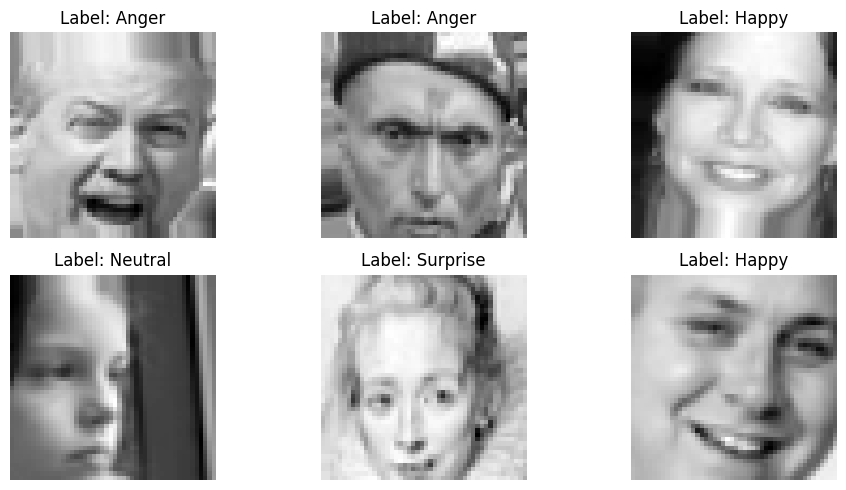

Shape of one batch (X): (64, 48, 48, 1)
Shape of one batch (y): (64, 7)


In [ ]:
# To visualize one batch of augmented images (just for clarity)
x_batch, y_batch = next(train_generator)

# Show a few augmented images from the batch
plt.figure(figsize=(10, 5))
for i in range(6):  # Displaying 6 images
    plt.subplot(2, 3, i+1)
    plt.imshow(x_batch[i].reshape(48, 48), cmap='gray')
    plt.title(f"Label: {CLASS_LABELS[np.argmax(y_batch[i])]}")  # Display the label
    plt.axis('off')
plt.tight_layout()
plt.show()

# Print the shape of one batch of data
print(f"Shape of one batch (X): {x_batch.shape}")  # Should be (64, 48, 48, 1)
print(f"Shape of one batch (y): {y_batch.shape}")  # Should be (64, 7)


## 5. Design a model

To develop the CNN architecture, we will begin by defining the input layer and the number of filters in the first convolutional layer. Then, we will add additional convolutional layers with increasing numbers of filters, followed by max-pooling layers to reduce the spatial dimensions of the feature maps. After the convolutional layers, we will add fully connected layers with ReLU activation to classify the emotions.

We will experiment with different numbers of convolutional layers, filter sizes, and fully connected layers to optimize the model performance. Additionally, we will use techniques such as dropout and batch normalization to prevent overfitting and improve the generalization capability of the model.

## 5.1 simple cnn architecture

In [ ]:
def cnn_model1():
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=((48,48,1))))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Conv2D(96, (3, 3), dilation_rate=(2, 2), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.4))

    model.add(Dense(7 , activation='softmax'))

    return model

In [ ]:
#opt = tf.keras.optimizers.Adam(0.001)
model_cnn1 = cnn_model1()
model_cnn1.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])
model_cnn1.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)                   │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_41               │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_40 (Conv2D)                   │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_42               │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_37 (MaxPooling2D)      │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_41 (Conv2D)                   │ (None, 12, 12, 96)          │          55,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_43               │ (None, 12, 12, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_38 (MaxPooling2D)      │ (None, 6, 6, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 3456)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 64)                  │         221,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_51 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 296,679 (1.13 MB)

 Trainable params: 296,295 (1.13 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping callback: stops training when the validation accuracy stops improving
checkpointer1 = [
    EarlyStopping(
        monitor='val_accuracy',        # Monitor validation accuracy
        verbose=1,                      # Print message when early stopping is triggered
        restore_best_weights=True,     # Restore model to the best weights
        mode="max",                     # 'max' for accuracy, 'min' for loss
        patience=15                     # Stop if no improvement for 10 epochs
    ),

    # ModelCheckpoint callback: save the model weights when validation accuracy improves
    ModelCheckpoint(
        'best_cnn1_model.keras',      # File name to save best weights
        monitor="val_accuracy",         # Monitor validation accuracy
        verbose=1,                      # Print message when weights are saved
        save_best_only=True,            # Save only the best weights
        mode="max"                    # Save when accuracy improves (mode=max for accuracy)

    )
]

In [ ]:
# Train the model with the callback
import time
# Record the start time
start_time1 = time.time()

history_cnn1 = model_cnn1.fit(
    train_generator,
    batch_size=50,
    epochs=60,
    validation_data=val_generator,
    callbacks=[checkpointer1]
)


# Record the end time
end_time1 = time.time()

# Calculate the time taken in seconds
time_taken1 = end_time1 - start_time1
print(f"Training time: {time_taken1} seconds")

Epoch 1/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3074 - loss: 1.6850
Epoch 1: val_accuracy improved from -inf to 0.34104, saving model to best_cnn1_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.3075 - loss: 1.6849 - val_accuracy: 0.3410 - val_loss: 1.6813
Epoch 2/60
445/449 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3512 - loss: 1.6122
Epoch 2: val_accuracy improved from 0.34104 to 0.37476, saving model to best_cnn1_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.3511 - loss: 1.6122 - val_accuracy: 0.3748 - val_loss: 1.5577
Epoch 3/60
445/449 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3555 - loss: 1.5949
Epoch 3: val_accuracy improved from 0.37476 to 0.37810, saving model to best_cnn1_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.3555 - loss: 1.5949 - val_accuracy: 0.3781 - val_loss: 1.5670
Epoch 4/60
444/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3640 - loss: 1.5688
Epoch 4: val_acc

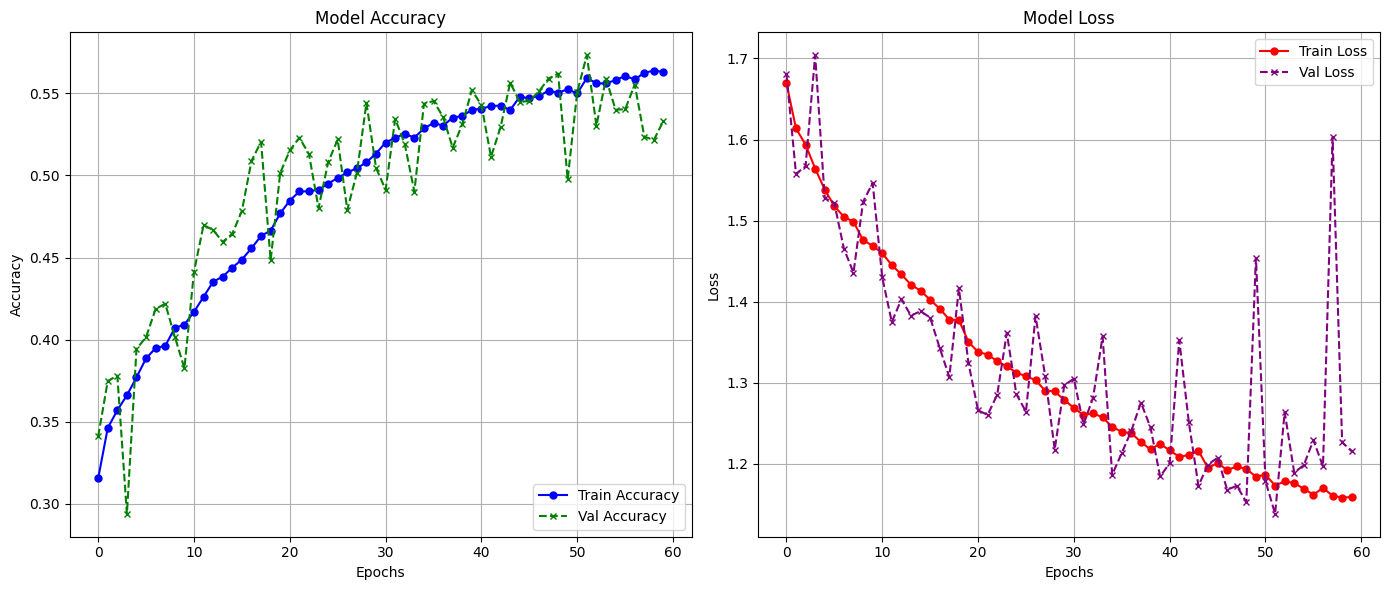

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and axes for plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the training and validation accuracy
ax1.plot(history_cnn1.history['accuracy'], label='Train Accuracy', color='b', linestyle='-', marker='o', markersize=5)
ax1.plot(history_cnn1.history['val_accuracy'], label='Val Accuracy', color='g', linestyle='--', marker='x', markersize=5)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Plot the training and validation loss
ax2.plot(history_cnn1.history['loss'], label='Train Loss', color='r', linestyle='-', marker='o', markersize=5)
ax2.plot(history_cnn1.history['val_loss'], label='Val Loss', color='purple', linestyle='--', marker='x', markersize=5)
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

# Display the plots
plt.tight_layout()
plt.show()


In [ ]:
# Assuming you have test data (X_test, y_test)
test_loss_bl1, test_accuracy_bl1 = model_cnn1.evaluate(x_test_reshape, y_test)
print(f'Test Loss: {test_loss_bl1}')
print(f'Test Accuracy: {test_accuracy_bl1}')

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5983 - loss: 1.0639
Test Loss: 1.0626354217529297
Test Accuracy: 0.6001671552658081


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

       Angry       0.50      0.56      0.52       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.45      0.29      0.36       528
       Happy       0.83      0.83      0.83       879
         Sad       0.47      0.50      0.48       594
    Surprise       0.78      0.63      0.70       416
     Neutral       0.52      0.70      0.60       626

    accuracy                           0.60      3589
   macro avg       0.51      0.50      0.50      3589
weighted avg       0.60      0.60      0.59      3589



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


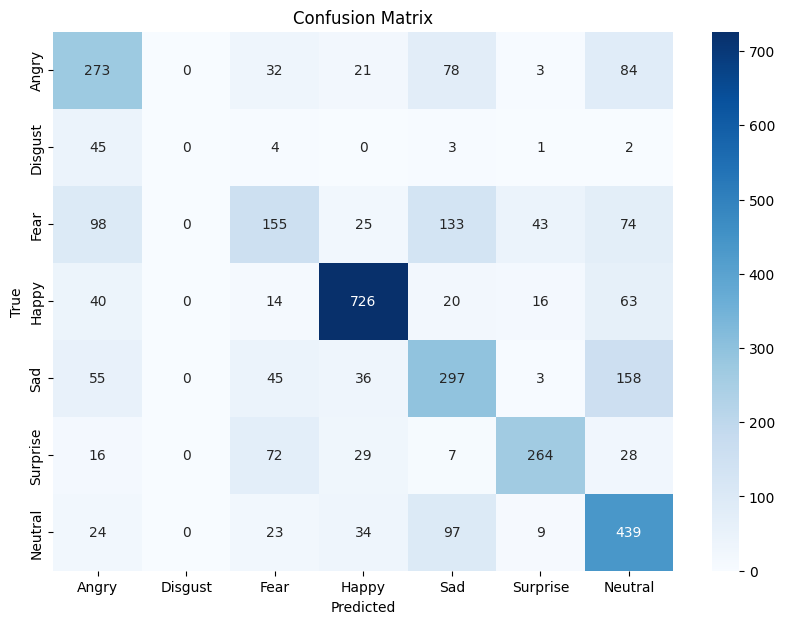

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Emotion mapping dictionary
emotion_mapping = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

# Predict on test data
y_pred_cnn1 = model_cnn1.predict(x_test_reshape)
y_pred_classes_cnn1 = y_pred_cnn1.argmax(axis=1)  # Get the class with max probability

# If your labels are one-hot encoded, convert them using argmax
y_true_cnn = y_test.argmax(axis=1)

# Classification report
print(classification_report(y_true_cnn, y_pred_classes_cnn1, target_names=emotion_mapping.values()))

# Confusion matrix
cm_cnn1 = confusion_matrix(y_true_cnn, y_pred_classes_cnn1)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm_cnn1, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_mapping.values(), yticklabels=emotion_mapping.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


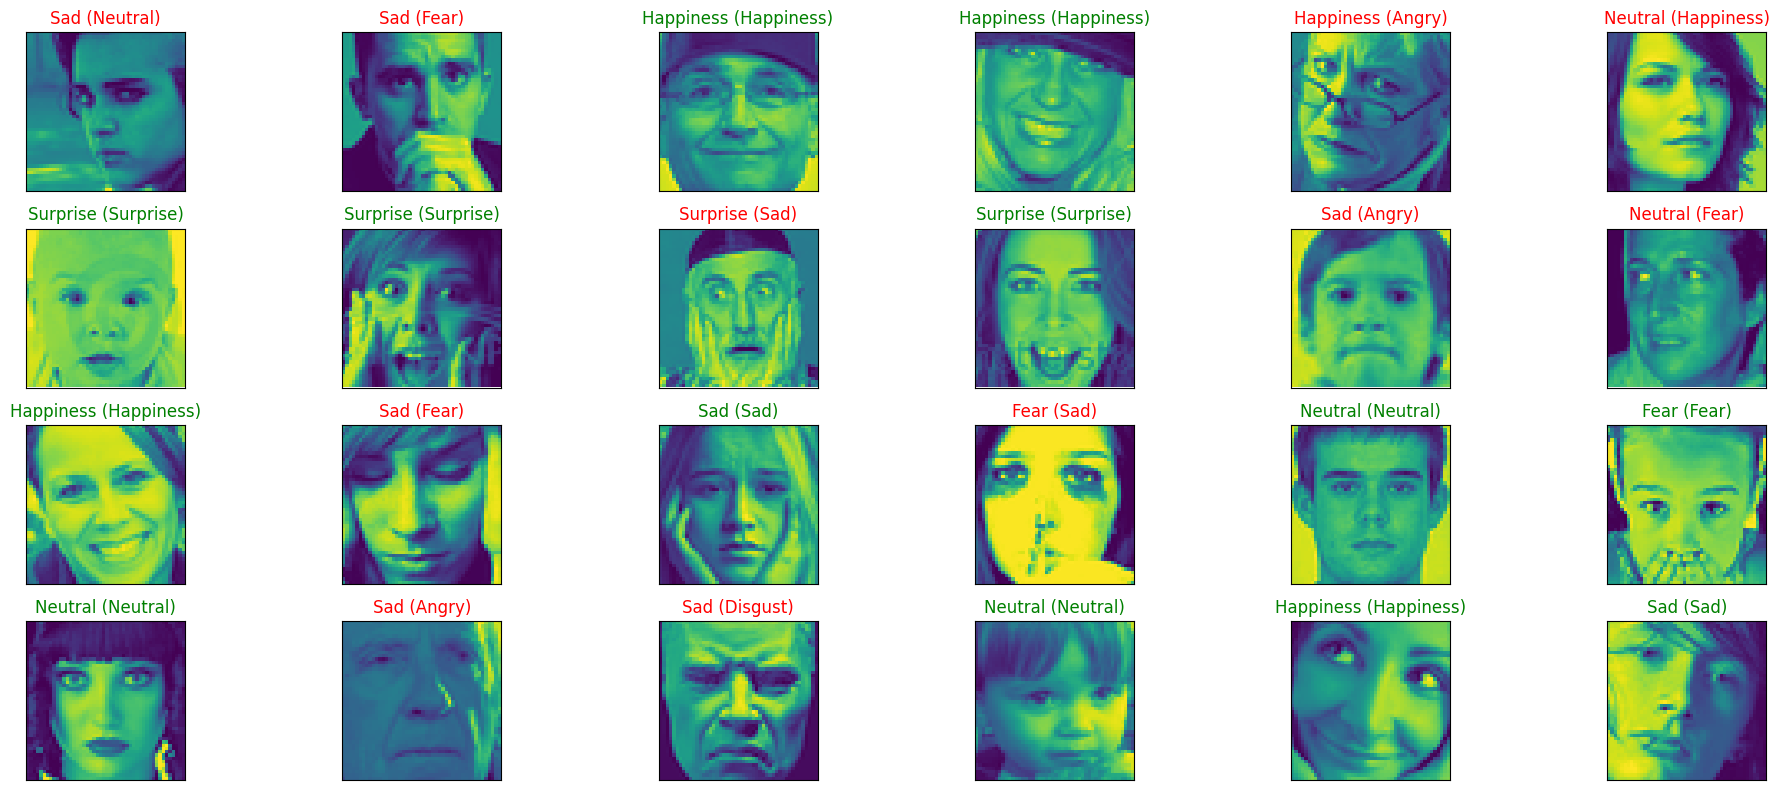

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

label_dict = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happiness', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Create a figure with a size to display 24 images
figure1 = plt.figure(figsize=(20, 8))

# Ensure the random indices are within the correct bounds
num_samples = x_test_reshape.shape[0]

# Select 24 random indices from the test set, ensuring that the indices do not exceed the available samples
for i, index in enumerate(np.random.choice(num_samples, size=24, replace=False)):
    ax = figure1.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_test_reshape[index]))  # Display the image

    # Get the predicted and true labels
    predict_index = label_dict[y_pred_cnn1[index].argmax()]  # Use .argmax() if y_pred_bl contains probabilities
    true_index = label_dict[np.argmax(y_test, axis=1)[index]]

    # Set the title of each subplot, using green for correct predictions and red for incorrect
    ax.set_title("{} ({})".format(predict_index, true_index),
                 color="green" if predict_index == true_index else "red")

# Display the plot
plt.tight_layout()
plt.show()


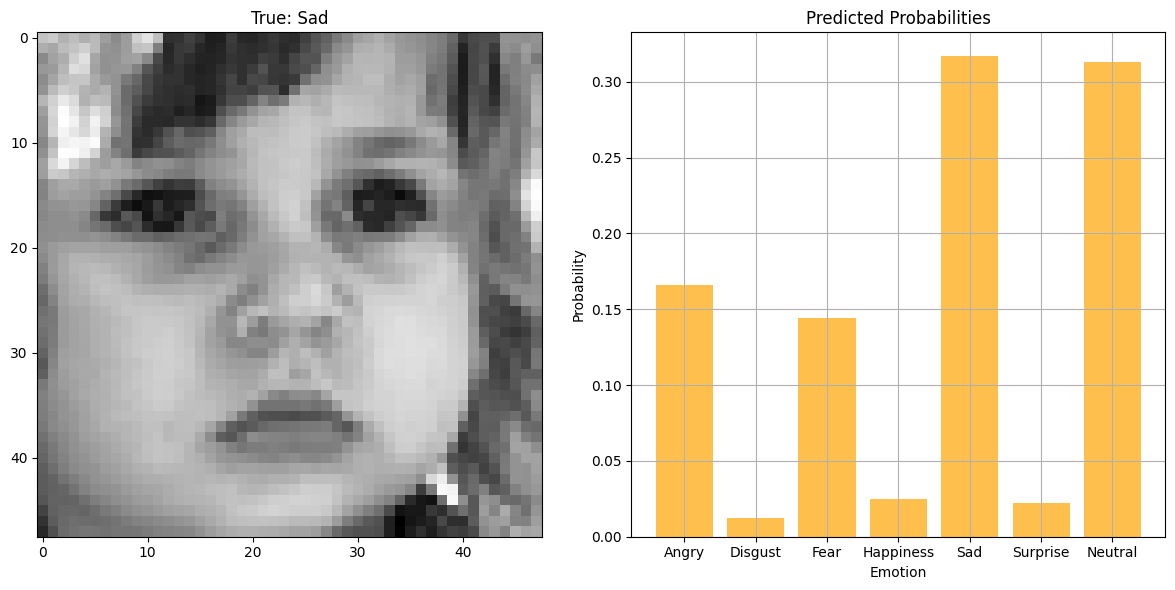

In [ ]:
plot_image_and_emotion(x_test_reshape, y_test.argmax(axis=1), y_pred_cnn1, 123,emotions=label_dict)

In [ ]:
# Save the model to a file
model_cnn1.save('emotion_recognition_model_cnn1.h5')

## 5.2.Changing learning rate and add some couch  and number of epochs

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping callback: stops training when the validation accuracy stops improving
checkpointer3 = [
    EarlyStopping(
        monitor='val_accuracy',        # Monitor validation accuracy
        verbose=1,                      # Print message when early stopping is triggered
        restore_best_weights=True,     # Restore model to the best weights
        mode="max",                     # 'max' for accuracy, 'min' for loss
        patience=10                     # Stop if no improvement for 10 epochs
    ),

    # ModelCheckpoint callback: save the best model weights when validation accuracy improves
    ModelCheckpoint(
        'best_model_mobileV2.keras',    # Save best model in .keras format
        monitor="val_accuracy",         # Monitor validation accuracy
        verbose=1,                      # Print message when model is saved
        save_best_only=True,            # Save only the best model
        mode="max",                     # Save when accuracy improves (mode=max for accuracy)
        save_weights_only=False         # Save the entire model (architecture + weights)
    )
]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization

def cnn_model_per3():
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))


    model.add(Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Second Convolutional Block
    model.add(Conv2D(96, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Flatten the features into a 1D vector
    model.add(Flatten())

    # First Dense Layer
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    # Second Dense Layer
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    # Output Layer for 7-class classification
    model.add(Dense(7, activation='softmax'))

    return model


In [ ]:
#opt = tf.keras.optimizers.Adam(0.001)
model3 = cnn_model_per3()
model3.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])
model3.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 96)          │          55,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 6, 6, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 6, 6, 128)           │         110,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 6, 6, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 343,271 (1.31 MB)

 Trainable params: 342,247 (1.31 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
# Train the model with the callback
import time
# Record the start time
start_time3 = time.time()

history3 = model3.fit(
    train_generator,
    batch_size=80,
    epochs=40,
    validation_data=val_generator,
    callbacks=checkpointer3
)


# Record the end time
end_time3 = time.time()

# Calculate the time taken in seconds
time_taken3 = end_time3 - start_time3
print(f"Training time: {time_taken3} seconds")

Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.2020 - loss: 2.2045
Epoch 1: val_accuracy improved from -inf to 0.24742, saving model to best_model_mobileV2.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 257s 560ms/step - accuracy: 0.2021 - loss: 2.2041 - val_accuracy: 0.2474 - val_loss: 1.9231
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.2733 - loss: 1.8026
Epoch 2: val_accuracy improved from 0.24742 to 0.28782, saving model to best_model_mobileV2.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 244s 544ms/step - accuracy: 0.2733 - loss: 1.8026 - val_accuracy: 0.2878 - val_loss: 1.8108
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.3485 - loss: 1.6597
Epoch 3: val_accuracy improved from 0.28782 to 0.41404, saving model to best_model_mobileV2.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 249s 553ms/step - accuracy: 0.3485 - loss: 1.6596 - val_accuracy: 0.4140 - val_loss: 1.5172
Epoch 4/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.3879 - loss: 1.5645
Epoch

In [ ]:
# Train the model with the callback
import time
# Record the start time
start_time3 = time.time()

history3 = model3.fit(
    train_generator,
    batch_size=150,
    epochs=10,
    validation_data=val_generator,
    callbacks=checkpointer3
)


# Record the end time
end_time3 = time.time()

# Calculate the time taken in seconds
time_taken3 = end_time3 - start_time3
print(f"Training time: {time_taken3} seconds")

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.5657 - loss: 1.1511
Epoch 1: val_accuracy did not improve from 0.58735
449/449 ━━━━━━━━━━━━━━━━━━━━ 270s 594ms/step - accuracy: 0.5657 - loss: 1.1511 - val_accuracy: 0.4556 - val_loss: 1.3842
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.5655 - loss: 1.1587
Epoch 2: val_accuracy did not improve from 0.58735
449/449 ━━━━━━━━━━━━━━━━━━━━ 290s 530ms/step - accuracy: 0.5655 - loss: 1.1587 - val_accuracy: 0.5848 - val_loss: 1.0802
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.5648 - loss: 1.1416
Epoch 3: val_accuracy did not improve from 0.58735
449/449 ━━━━━━━━━━━━━━━━━━━━ 258s 520ms/step - accuracy: 0.5648 - loss: 1.1416 - val_accuracy: 0.5765 - val_loss: 1.0903
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.5762 - loss: 1.1294
Epoch 4: val_accuracy improved from 0.58735 to 0.59487, saving model to best_model_mobileV2.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 266s 

113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.6207 - loss: 0.9900
Test Acc: 0.6196712255477905


113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step


## 5.3  Transfer Learning with MobileNetV2

#### Step 1: Import Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#### 2. Data Preprocessing

In [ ]:
# Convert grayscale images to RGB
def preprocess_input_images(images):
    return np.repeat(images, 3, axis=-1)  # Convert (48, 48, 1) to (48, 48, 3)

# Preprocess the data
x_train_reshape_rgb = preprocess_input_images(x_train_reshape)
x_val_reshape_rgb = preprocess_input_images(x_val_reshape)
x_test_reshape_rgb = preprocess_input_images(x_test_reshape)

print("Reshaped arrays:")
print("X_train:", x_train_reshape_rgb.shape)
print("X_val:", x_val_reshape_rgb.shape)
print("X_test:", x_test_reshape_rgb.shape)


Reshaped arrays:
X_train: (28709, 48, 48, 3)
X_val: (3589, 48, 48, 3)
X_test: (3589, 48, 48, 3)


#### Setting up ImageDataGenerators

In [ ]:
# Initialize ImageDataGenerator with augmentations for training
datagen_train_cnn2 = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest',
    zoom_range=0.2
)

# Initialize ImageDataGenerator for validation (no augmentation)
datagen_val_cnn2 = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

In [ ]:
# Fit the datagen_train to the training data (for statistics)
datagen_train_cnn2.fit(x_train_reshape_rgb)

In [ ]:
train_generator_cnn2 = datagen_train_cnn2.flow(x_train_reshape_rgb, y_train, batch_size=64)
val_generator_cnn2 = datagen_val_cnn2.flow(x_val_reshape_rgb, y_val, batch_size=64)

#### Step 3: Build the Model with MobileNetV2 as Feature Extractor

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Resizing
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# Function to create the model
def cnn_model_mobilenetv2(input_shape=(48, 48, 3), num_classes=7):
    model = Sequential()

    # Add Resizing layer to resize input to (224, 224, 3) before MobileNetV2
    model.add(Resizing(224, 224, input_shape=input_shape))  # Resize the image to 224x224

    # Load the MobileNetV2 model, pre-trained on ImageNet, without the top layer
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

    # Freeze the base model layers to avoid training them during the initial training phase
    base_model.trainable = False

    # Add the MobileNetV2 base model to the custom model
    model.add(base_model)

    # Add global average pooling to reduce the dimensions
    model.add(GlobalAveragePooling2D())

    # Add additional fully connected layers
    model.add(Dense(512, activation='relu'))  # First dense layer with 512 units
    model.add(Dropout(0.5))  # Dropout for regularization

    model.add(Dense(256, activation='relu'))  # Second dense layer with 256 units
    model.add(Dropout(0.5))  # Dropout for regularization

    model.add(Dense(128, activation='relu'))  # Third dense layer with 128 units
    model.add(Dropout(0.5))  # Dropout for regularization

    # Add the output layer with softmax activation for multi-class classification
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Initialize the model
model_cnn2 = cnn_model_mobilenetv2(input_shape=(48, 48, 3), num_classes=7)

# Compile the model
model_cnn2.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary to check the architecture
model_cnn2.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resizing_6 (Resizing)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_58 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_59 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_60 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,078,983 (11.75 MB)

 Trainable params: 820,999 (3.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

####Step 4: Set Up Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping callback: stops training when the validation accuracy stops improving
checkpointer_cnn2 = [
    EarlyStopping(
        monitor='val_accuracy',        # Monitor validation accuracy
        verbose=1,                      # Print message when early stopping is triggered
        restore_best_weights=True,     # Restore model to the best weights
        mode="max",                     # 'max' for accuracy, 'min' for loss
        patience=6                     # Stop if no improvement for 10 epochs
    ),

    # ModelCheckpoint callback: save the best model weights when validation accuracy improves
    ModelCheckpoint(
        'best_model_mobileV2.keras',    # Save best model in .keras format
        monitor="val_accuracy",         # Monitor validation accuracy
        verbose=1,                      # Print message when model is saved
        save_best_only=True,            # Save only the best model
        mode="max",                     # Save when accuracy improves (mode=max for accuracy)
        save_weights_only=False         # Save the entire model (architecture + weights)
    )
]


In [ ]:
historycnn2 = model_cnn2.fit(
    train_generator_cnn2,
    validation_data=val_generator_cnn2,
    batch_size=60,
    epochs=80,
    callbacks=checkpointer_cnn2
)

Epoch 1/80


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2309 - loss: 1.9129
Epoch 1: val_accuracy improved from -inf to 0.36835, saving model to best_model_mobileV2.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 69s 119ms/step - accuracy: 0.2311 - loss: 1.9124 - val_accuracy: 0.3683 - val_loss: 1.6167
Epoch 2/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3260 - loss: 1.6805
Epoch 2: val_accuracy improved from 0.36835 to 0.40568, saving model to best_model_mobileV2.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.3260 - loss: 1.6805 - val_accuracy: 0.4057 - val_loss: 1.5712
Epoch 3/80
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3572 - loss: 1.6228
Epoch 3: val_accuracy improved from 0.40568 to 0.41571, saving model to best_model_mobileV2.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.3572 - loss: 1.6227 - val_accuracy: 0.4157 - val_loss: 1.5392
Epoch 4/80
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3713 - loss: 1.6058
Epoch 4: val_a

In [ ]:
test_loss2, test_accuracy2 = model2.evaluate(x_test_reshape, y_test)
print(f"Test Loss: {test_loss2}")
print(f"Test Accuracy: {test_accuracy2}")


## 5.4. make data blanced

In [ ]:
data_bl=pd.read_csv('data.csv')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Target number of samples per class
target_samples = 2500

balanced_data = []

# Data augmentation setup
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Separate the dataset into groups by emotion
groups = data_bl.groupby('emotion')

# Loop through each emotion group
for emotion, group in groups:
    num_samples = len(group)
    print(f'Class {emotion} has {num_samples} samples')

    if num_samples < target_samples:
        # Oversample by generating augmented data
        minority_class = group.copy()

        # Prepare minority class images
        X_minority = np.stack(minority_class['pixels'].apply(lambda x: np.array(x.split(), dtype='float32')).values)
        X_minority = X_minority.reshape(-1, 48, 48, 1)  # Reshape to (num_samples, height, width, channels)

        # Calculate how many new samples are needed
        num_needed = target_samples - num_samples
        augmented_images = []

        # Generate the required number of samples
        num_generated = 0
        while num_generated < num_needed:
            # Generate a small batch of augmented images
            for batch in datagen.flow(X_minority, batch_size=32):  # You can still use a batch size of 32
                augmented_images.append(batch)
                num_generated += batch.shape[0]  # Number of generated images in this batch
                if num_generated >= num_needed:
                    break

        # Concatenate the augmented images and trim to the exact number needed
        augmented_images = np.concatenate(augmented_images, axis=0)[:num_needed]

        # Create new pixels from augmented images
        new_pixels = [' '.join(map(str, img.flatten().astype(int))) for img in augmented_images]
        new_rows = pd.DataFrame({'emotion': [emotion] * len(new_pixels), 'pixels': new_pixels, 'Usage': [group['Usage'].iloc[0]] * len(new_pixels)})

        # Append original and new rows
        balanced_data.append(pd.concat([minority_class, new_rows]))

    elif num_samples > target_samples:
        # Undersample if the class has more than target_samples
        # Sample randomly to reduce the size to target_samples
        undersampled_class = group.sample(target_samples, random_state=42)
        balanced_data.append(undersampled_class)

    else:
        # Class already has the target number of samples
        balanced_data.append(group)

# Combine all classes into a balanced dataset
balanced_dataset = pd.concat(balanced_data)

# Shuffle the dataset
balanced_dataset = balanced_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Print the class distribution of the new dataset
print("New balanced dataset shape:", balanced_dataset.shape)
print(balanced_dataset['emotion'].value_counts())


Class 0 has 4953 samples
Class 1 has 547 samples
Class 2 has 5121 samples
Class 3 has 8989 samples
Class 4 has 6077 samples
Class 5 has 4002 samples
Class 6 has 6198 samples
New balanced dataset shape: (17500, 3)
emotion
0    2500
3    2500
1    2500
4    2500
5    2500
2    2500
6    2500
Name: count, dtype: int64


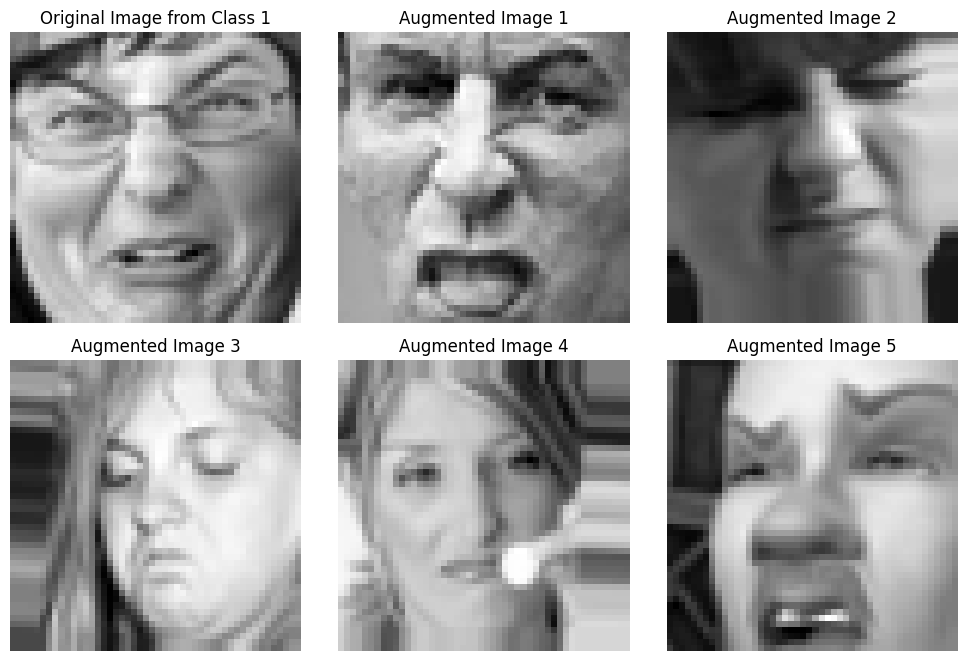

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Function to convert 'pixels' string to numpy array
def string_to_image(pixel_string):
    pixel_values = np.array(pixel_string.split(), dtype='float32')
    return pixel_values.reshape(48, 48)  # Reshape to 48x48 image

# Extract the rows of the balanced dataset where new (augmented) images were added
augmented_images_data = balanced_dataset[balanced_dataset['Usage'] == 'Training']  # Assuming 'Usage' column contains 'Training' for new samples

# Select a few random augmented images (for example, 5 from class 1)
class_1_augmented_images = augmented_images_data[augmented_images_data['emotion'] == 1]

# Plot the original and some of the augmented images
plt.figure(figsize=(10, 10))

# Plot the original image from class 1 (for comparison)
original_image = data_bl[data_bl['emotion'] == 1].iloc[0]['pixels']
original_image = string_to_image(original_image)

plt.subplot(3, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image from Class 1')
plt.axis('off')

# Plot some augmented images from the new dataset
for i in range(1, 6):  # Show 5 augmented images
    augmented_image = class_1_augmented_images.iloc[i]['pixels']
    augmented_image = string_to_image(augmented_image)

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image, cmap='gray')
    plt.title(f'Augmented Image {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Load the augmented data (assuming you've already combined original and augmented data into balanced_dataset)
data_plot_bl = balanced_dataset.copy()  # Make a deep copy of the original balanced_dataset


# Define the class labels and create a mapping
CLASS_LABELS2 = ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', 'Surprise']
emotion_map2 = {i: label for i, label in enumerate(CLASS_LABELS2)}

# Map numeric emotion values to class labels
data_plot_bl['emotion_labels'] = data_plot_bl['emotion'].map(emotion_map2)

# Group by 'Usage' and count occurrences of each 'emotion_labels' within each usage category
usage_emotion_counts = data_plot_bl.groupby(['Usage', 'emotion_labels']).size().unstack(fill_value=0)

# Reset the index to have 'Usage' as a column
usage_emotion_counts = usage_emotion_counts.reset_index()

# Plot the result using Plotly for better visualization
fig2 = px.bar(
    usage_emotion_counts,
    x='Usage',
    y=usage_emotion_counts.columns[1:],  # All columns except the first one (Usage)
    title="Number of Each Emotion Label in Different Usage Categories (After Augmentation)",
    labels={'value': 'Number of Images', 'emotion_labels': 'Emotion'},
    barmode='stack'
)

# Update layout for better readability
fig2.update_layout(
    xaxis_title="Usage Type",
    yaxis_title="Number of Instances",
    legend_title="Emotion Label"
)

# Show the plot
fig2.show()


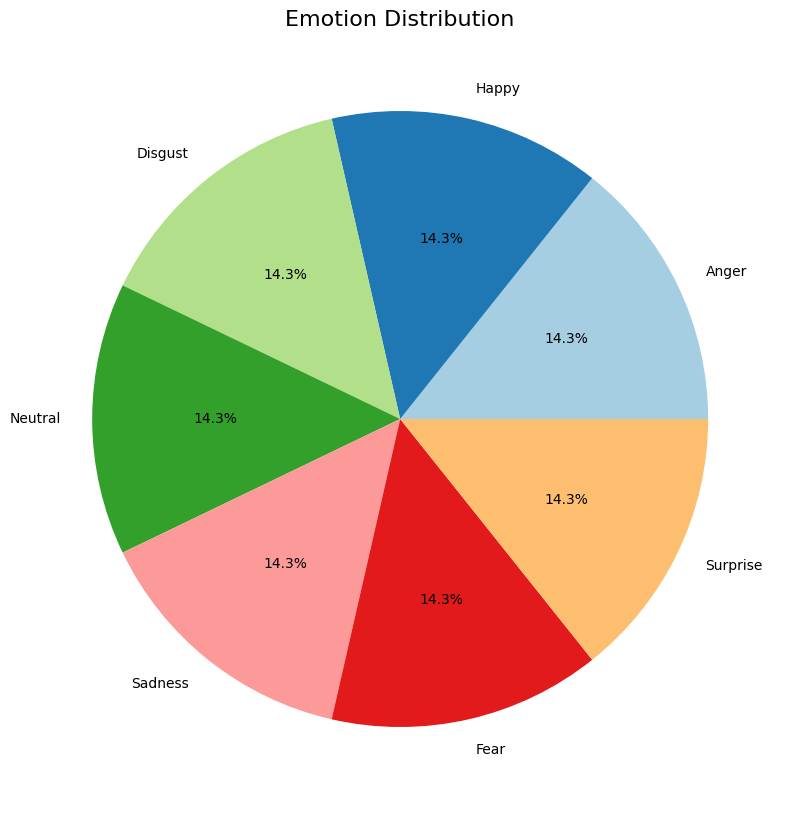

In [ ]:
data_pl2 =  balanced_dataset.copy()
# Define the CLASS_LABELS
CLASS_LABELS2 = ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', 'Surprise']

# Replace the emotion column with the CLASS_LABELS2 (if it's a numeric code or map to the appropriate class)
# Ensure that your 'emotion' column contains the correct values corresponding to the emotion classes.
# If 'emotion' is already categorical or string type, you may not need this step.
# Assuming data['emotion'] is an index or numeric code, we can map them as follows:

# Create a dictionary to map numerical values to emotion labels
emotion_map2 = {i: label for i, label in enumerate(CLASS_LABELS2)}

# If 'data['emotion']' contains numerical values (e.g., 0, 1, 2, 3, ...), we can map them to the labels
data_pl2['emotion'] = data_pl2['emotion'].map(emotion_map2)

# Now, plot the pie chart
country_counts2 = data_pl2['emotion'].value_counts()

# Plot
plt.figure(figsize=(12, 10))
plt.pie(country_counts2, labels=country_counts2.index, autopct='%1.1f%%', colors=plt.cm.Paired(np.arange(len(country_counts2))))
plt.title('Emotion Distribution', fontsize=16)
plt.show()


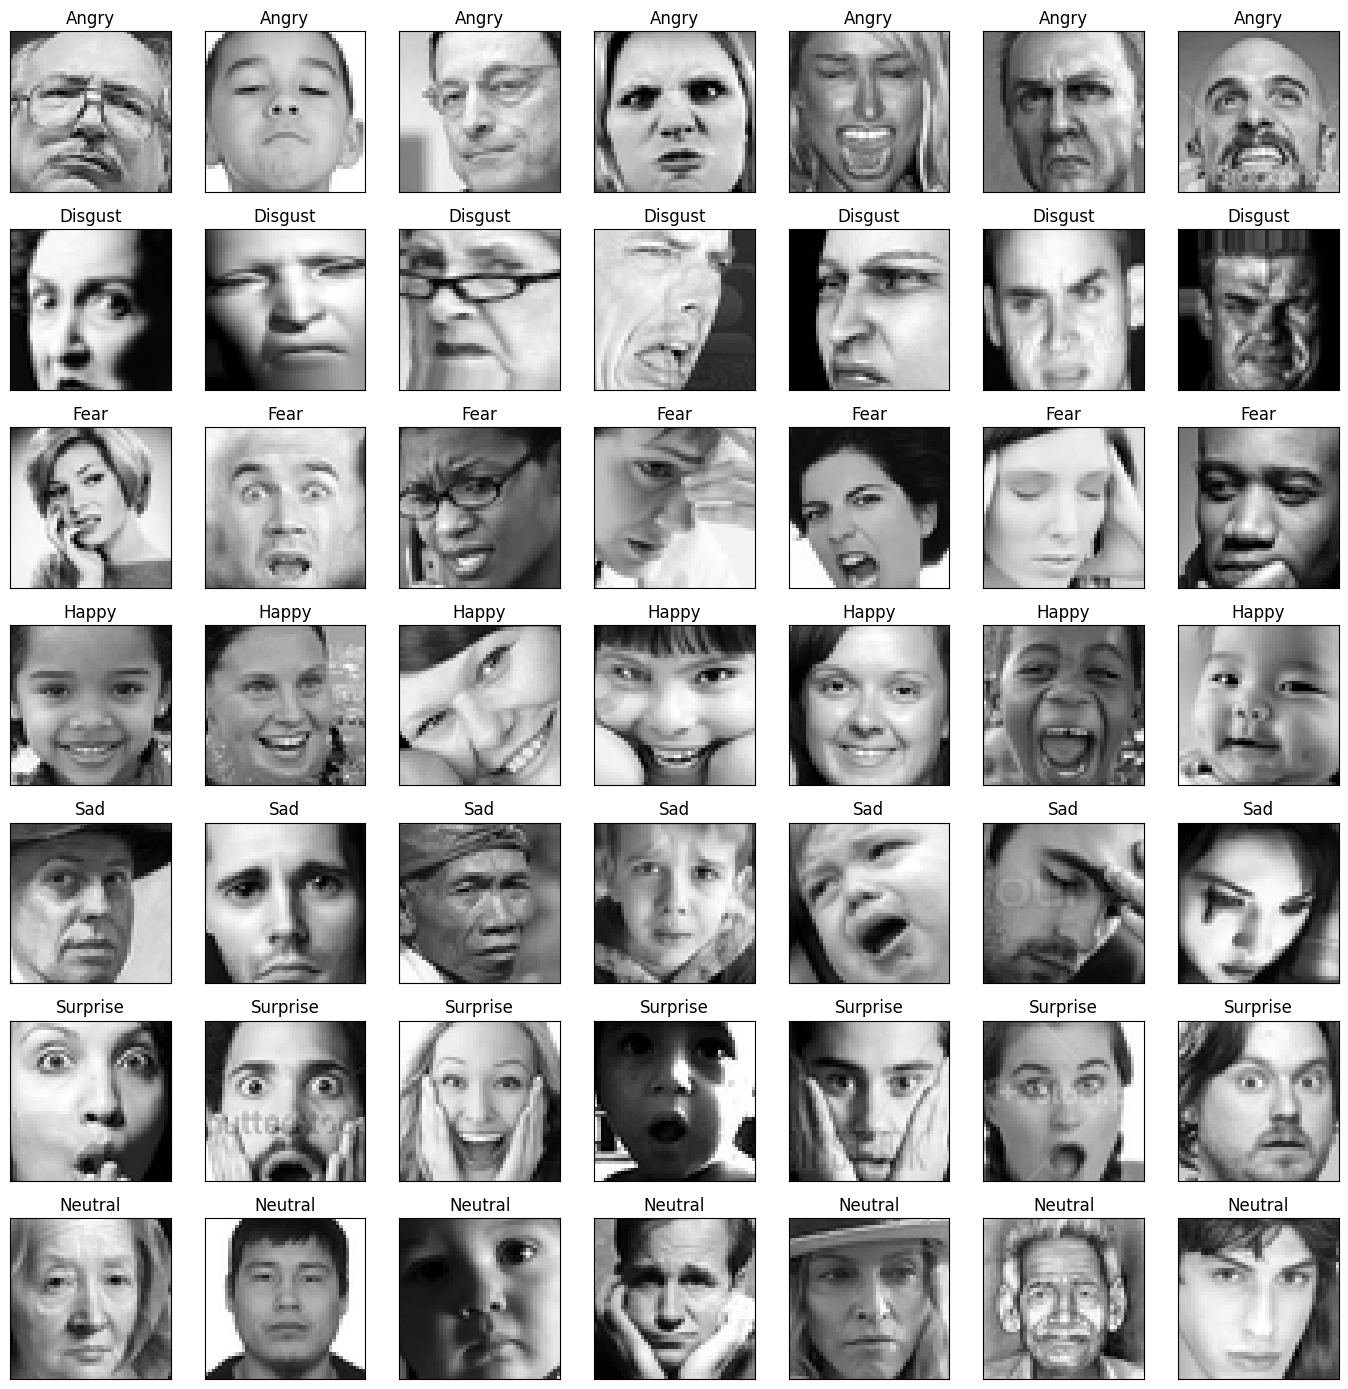

In [ ]:
from matplotlib import pyplot
import numpy as np

# Assuming balanced_dataset is your balanced DataFrame and emotion_mapping is defined
emotion_mapping = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

fig = pyplot.figure(1, (14, 14))

# Initialize `k` for indexing through images
k = 0

# Loop through each unique emotion in the balanced dataset
for label in sorted(balanced_dataset.emotion.unique()):
    emotion_data = balanced_dataset[balanced_dataset.emotion == label]

    # Reset `k` for each emotion class
    for j in range(min(7, len(emotion_data))):  # Limit to 7 images per emotion
        px = emotion_data.pixels.iloc[k]

        # Split the pixel data and reshape into a 48x48 image
        px = np.array(px.split(' ')).reshape(48, 48).astype('float32')

        # Increment `k` for each image processed
        k += 1

        # Plot each image
        ax = pyplot.subplot(7, 7, k)
        ax.imshow(px, cmap='gray')
        ax.set_xticks([])  # Hide x-axis ticks
        ax.set_yticks([])  # Hide y-axis ticks
        ax.set_title(emotion_mapping[label])  # Set title using emotion_mapping

    # Adjust layout to prevent overlapping
    pyplot.tight_layout()

# Show the plot
pyplot.show()


In [ ]:
import pandas as pd
import plotly.express as px


data_plot_bl5 = balanced_dataset.copy()
# Count the number of occurrences for each label in the 'Usage' column
usage_counts = data_plot_bl5['Usage'].value_counts().reset_index()
usage_counts.columns = ['Usage', 'Count']

# Create a bar chart using Plotly
fig = px.bar(usage_counts, x='Usage', y='Count', title="Distribution of Labels in Usage Column", color='Usage')

# Update axes titles and layout
fig.update_xaxes(title="Usage Type")
fig.update_yaxes(title="Number of Instances")
fig.update_layout(showlegend=False)

# Show the plot
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Assuming balanced_dataset is already defined and available
data_plot5 = balanced_dataset.copy()

# Grouping by 'Usage' and 'emotion' and counting occurrences
usage_emotion_counts = data_plot5.groupby(['Usage', 'emotion']).size().reset_index(name='count')

# Mapping emotion indices to emotion names and emojis
CLASS_LABELS = ['Anger 😡', 'Disgust 🤢', 'Fear 😨', 'Happy 😊', 'Neutral 😐', 'Sadness 😢', 'Surprise 😲']

# Ensure that 'emotion' is integer-based, so it can be used as an index
usage_emotion_counts['emotion'] = usage_emotion_counts['emotion'].astype(int)

# Map the integer emotion values to emotion labels
usage_emotion_counts['emotion_label'] = usage_emotion_counts['emotion'].map(lambda x: CLASS_LABELS[x])

# Plot the data using Plotly
fig3 = px.bar(usage_emotion_counts,
             x='emotion_label', y='count',
             color='Usage',
             title='Emotion Distribution Across Different Usage Types',
             labels={'emotion_label': 'Emotion', 'count': 'Number of Images', 'Usage': 'Usage Type'},
             barmode='stack')

# Customize layout
fig3.update_layout(
    xaxis_title="Emotion",
    yaxis_title="Number of Images",
    showlegend=True,
    title={'text': 'Emotion Distribution in Training, PublicTest, and PrivateTest', 'x': 0.5, 'xanchor': 'center'}
)

# Show the plot
fig3.show()


In [ ]:
# Split the dataset into training, validation, and testing based on the 'Usage' column
train_balanced_dataset = balanced_dataset[balanced_dataset['Usage'] == 'Training']
val_balanced_dataset = balanced_dataset[balanced_dataset['Usage'] == 'PublicTest']  # Or 'PrivateTest' based on your need
test_balanced_dataset = balanced_dataset[balanced_dataset['Usage'] == 'PrivateTest']  # If you have a separate validation set

# Check the split
print(f"Training balanced_dataset shape: {train_balanced_dataset.shape}")
print(f"Testing balanced_dataset shape: {test_balanced_dataset.shape}")
print(f"Validation balanced_dataset shape: {val_balanced_dataset.shape}")

Training balanced_dataset shape: (14422, 3)
Testing balanced_dataset shape: (1544, 3)
Validation balanced_dataset shape: (1534, 3)


In [ ]:
# Convert the 'pixels' column into NumPy arrays
def convert_pixels(dataset):
    return np.array(list(map(str.split, dataset['pixels'])), dtype=np.float32)

train_data_arr_balanced = convert_pixels(train_balanced_dataset)
val_data_arr_balanced = convert_pixels(val_balanced_dataset)
test_data_arr_balanced = convert_pixels(test_balanced_dataset)

print("Shape of raw pixel arrays:")
print("X_train:",train_data_arr_balanced.shape)
print("X_val:", val_data_arr_balanced.shape)
print("X_test:", test_data_arr_balanced.shape)

Shape of raw pixel arrays:
X_train: (14422, 2304)
X_val: (1534, 2304)
X_test: (1544, 2304)


In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert emotion labels to one-hot encoding
y_train_balanced = to_categorical(train_balanced_dataset['emotion'], num_classes=7)
y_val_balanced = to_categorical(val_balanced_dataset['emotion'], num_classes=7)
y_test_balanced = to_categorical(test_balanced_dataset['emotion'], num_classes=7)

print("One-hot encoded labels:")
print("y_train:", y_train_balanced.shape)
print("y_val:", y_val_balanced.shape)
print("y_test:", y_test_balanced.shape)

One-hot encoded labels:
y_train: (14422, 7)
y_val: (1534, 7)
y_test: (1544, 7)


In [ ]:
# Check the range of pixel values  normalization
print(f"Pixel value range  normalization:")
print(f"Train data - min: {train_data_arr_balanced.min()}, max: {train_data_arr_balanced.max()}")
print(f"Validation data - min: {val_data_arr_balanced.min()}, max: {val_data_arr_balanced.max()}")
print(f"Test data - min: {test_data_arr_balanced.min()}, max: {test_data_arr_balanced.max()}")

Pixel value range  normalization:
Train data - min: 0.0, max: 255.0
Validation data - min: 0.0, max: 255.0
Test data - min: 0.0, max: 255.0


In [ ]:
# Normalize pixel values to the range 0-1
train_data_arr_balanced /= 255.0
val_data_arr_balanced /= 255.0
test_data_arr_balanced /= 255.0

# Check the range of pixel values after normalization
print(f"Pixel value range after normalization:")
print(f"Train data - min: {train_data_arr_balanced.min()}, max: {train_data_arr_balanced.max()}")
print(f"Validation data - min: {val_data_arr_balanced.min()}, max: {val_data_arr_balanced.max()}")
print(f"Test data - min: {test_data_arr_balanced.min()}, max: {test_data_arr_balanced.max()}")

Pixel value range after normalization:
Train data - min: 0.0, max: 1.0
Validation data - min: 0.0, max: 1.0
Test data - min: 0.0, max: 1.0


In [ ]:
# Reshape the arrays to (samples, 48, 48, 1)
x_train_reshape_bl = train_data_arr_balanced.reshape(-1, 48, 48, 1)
x_val_reshape_bl = val_data_arr_balanced.reshape(-1, 48, 48, 1)
x_test_reshape_bl = test_data_arr_balanced.reshape(-1, 48, 48, 1)

print("Reshaped arrays:")
print("X_train:", x_train_reshape_bl.shape)
print("X_val:", x_val_reshape_bl.shape)
print("X_test:", x_test_reshape_bl.shape)

Reshaped arrays:
X_train: (14422, 48, 48, 1)
X_val: (1534, 48, 48, 1)
X_test: (1544, 48, 48, 1)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from matplotlib import pyplot as plt


# Setup for data augmentation
datagen_train_bl = ImageDataGenerator(
    rotation_range=10,  # Rotate the images slightly
    horizontal_flip=True,  # Flip images horizontally
    width_shift_range=0.1,  # Shift images horizontally
    height_shift_range=0.1,  # Shift images vertically
    fill_mode='nearest',  # Fill pixels when shifting
    zoom_range = 0.2      # Random zoom
)


datagen_val_bl = ImageDataGenerator(   width_shift_range = 0.1,
                               height_shift_range = 0.1,
                               horizontal_flip = True,
                               zoom_range = 0.2)

In [ ]:
# Fit the datagen to the training data
datagen_train_bl.fit(x_train_reshape_bl)

In [ ]:
# We do NOT fit the validation data generator, as we should not augment validation data.
# The validation generator should simply yield original images.

# Create the data generators for both training and validation sets
train_generator_bl = datagen_train_bl.flow(x_train_reshape_bl, y_train_balanced, batch_size=64)
val_generator_bl = datagen_val_bl.flow(x_val_reshape_bl, y_val_balanced, batch_size=64)

### Define Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# EarlyStopping: Stop training if validation accuracy doesn't improve
early_stopping = EarlyStopping(
    monitor='val_accuracy',         # Metric to monitor
    patience=10,                    # Stop after 10 epochs with no improvement
    verbose=1,                      # Print stopping information
    restore_best_weights=True       # Rollback to best weights
)

# ModelCheckpoint: Save the best model
model_checkpoint = ModelCheckpoint(
    'best_cnn3_model.keras',         # File name to save the model
    monitor='val_accuracy',         # Metric to monitor
    save_best_only=True,            # Save only if the model improves
    verbose=1,                      # Print save information
    mode="max"
)

# ReduceLROnPlateau: Adjust learning rate when validation accuracy plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',         # Metric to monitor
    factor=0.5,                     # Reduce learning rate by half
    patience=4,                     # After 5 epochs of no improvement
    verbose=1,                      # Print learning rate adjustment
    min_lr=1e-6                     # Minimum learning rate
)

# Combine callbacks
callbacks_bl = [early_stopping, model_checkpoint, reduce_lr]


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.models import Sequential

def cnn_model_bl():
    model = Sequential()
    input_shape = (48,48,1)
    model.add(Conv2D(64, (5, 5), input_shape=input_shape,activation='relu', padding='same'))
    model.add(Conv2D(64, (5, 5), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (5, 5),activation='relu',padding='same'))
    model.add(Conv2D(128, (5, 5),activation='relu',padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(256, (3, 3),activation='relu',padding='same'))
    model.add(Conv2D(256, (3, 3),activation='relu',padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(Activation('softmax'))



    return model

### 2. Define and Compile Your Model

In [ ]:
import tensorflow as tf

model_bl3=cnn_model_bl()
# Compile the model with categorical cross-entropy loss, adam optimizer, and accuracy metric
model_bl3.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

# Print summary
model_bl3.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)                   │ (None, 48, 48, 64)          │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 48, 48, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_37               │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 24, 24, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_36 (Conv2D)                   │ (None, 24, 24, 128)         │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_38               │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_39               │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_40               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_50 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 7)                   │             903 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 7)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 2,787,015 (10.63 MB)

 Trainable params: 2,785,863 (10.63 MB)

 Non-trainable params: 1,152 (4.50 KB)

### 3. Train the Model

In [ ]:
history_cnn3 = model_bl3.fit(
    train_generator_bl,
    validation_data=val_generator_bl,
    epochs=120,                          # Maximum number of epochs
    batch_size=100,
    callbacks=callbacks_bl,                # Add callbacks
    verbose=1                           # Show training progress
)

Epoch 1/120
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.1895 - loss: 2.0716
Epoch 1: val_accuracy improved from -inf to 0.20665, saving model to best_cnn3_model.keras
226/226 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.1896 - loss: 2.0712 - val_accuracy: 0.2066 - val_loss: 1.9363 - learning_rate: 0.0010
Epoch 2/120
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2405 - loss: 1.9039
Epoch 2: val_accuracy improved from 0.20665 to 0.20991, saving model to best_cnn3_model.keras
226/226 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.2406 - loss: 1.9038 - val_accuracy: 0.2099 - val_loss: 1.9818 - learning_rate: 0.0010
Epoch 3/120
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3030 - loss: 1.7733
Epoch 3: val_accuracy did not improve from 0.20991
226/226 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.3031 - loss: 1.7732 - val_accuracy: 0.1851 - val_loss: 1.9831 - learning_rate: 0.0010
Epoch 4/120
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.380

### 1. Evaluate the Model

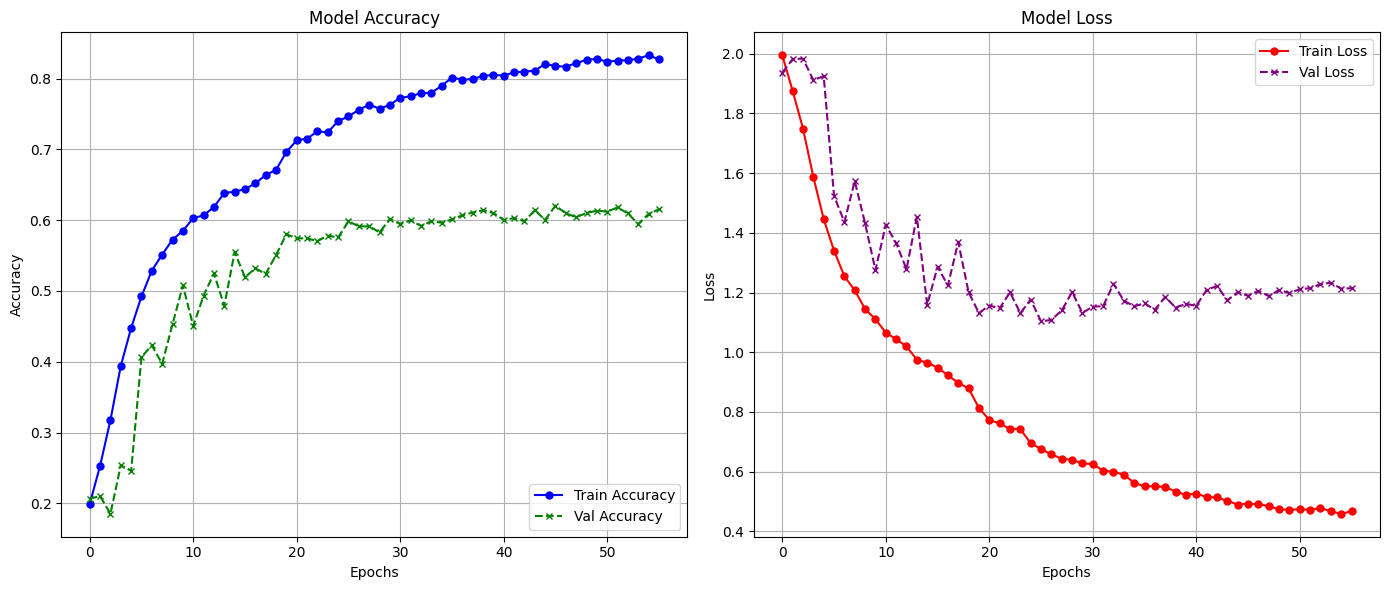

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and axes for plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the training and validation accuracy
ax1.plot(history_cnn3.history['accuracy'], label='Train Accuracy', color='b', linestyle='-', marker='o', markersize=5)
ax1.plot(history_cnn3.history['val_accuracy'], label='Val Accuracy', color='g', linestyle='--', marker='x', markersize=5)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Plot the training and validation loss
ax2.plot(history_cnn3.history['loss'], label='Train Loss', color='r', linestyle='-', marker='o', markersize=5)
ax2.plot(history_cnn3.history['val_loss'], label='Val Loss', color='purple', linestyle='--', marker='x', markersize=5)
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

# Display the plots
plt.tight_layout()
plt.show()


In [ ]:
# Assuming you have test data (X_test, y_test)
test_loss_bl, test_accuracy_bl = model_bl3.evaluate(x_test_reshape_bl, y_test_balanced)
print(f'Test Loss: {test_loss_bl}')
print(f'Test Accuracy: {test_accuracy_bl}')

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6278 - loss: 1.0838
Test Loss: 1.0661410093307495
Test Accuracy: 0.6366580128669739


### Evaluate per Emotion:

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

       Angry       0.57      0.63      0.60       243
     Disgust       0.89      0.73      0.80        55
        Fear       0.53      0.45      0.48       251
       Happy       0.83      0.80      0.82       251
         Sad       0.55      0.44      0.49       242
    Surprise       0.75      0.78      0.76       258
     Neutral       0.54      0.70      0.61       244

    accuracy                           0.64      1544
   macro avg       0.67      0.65      0.65      1544
weighted avg       0.64      0.64      0.63      1544



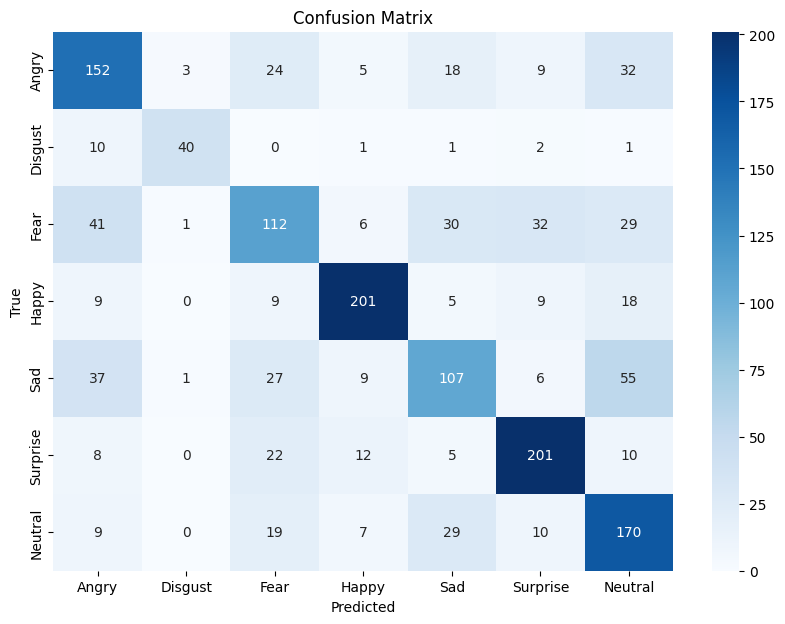

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Emotion mapping dictionary
emotion_mapping = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

# Predict on test data
y_pred_bl = model_bl3.predict(x_test_reshape_bl)
y_pred_classes = y_pred_bl.argmax(axis=1)  # Get the class with max probability

# If your labels are one-hot encoded, convert them using argmax
y_true = y_test_balanced.argmax(axis=1)

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=emotion_mapping.values()))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_mapping.values(), yticklabels=emotion_mapping.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


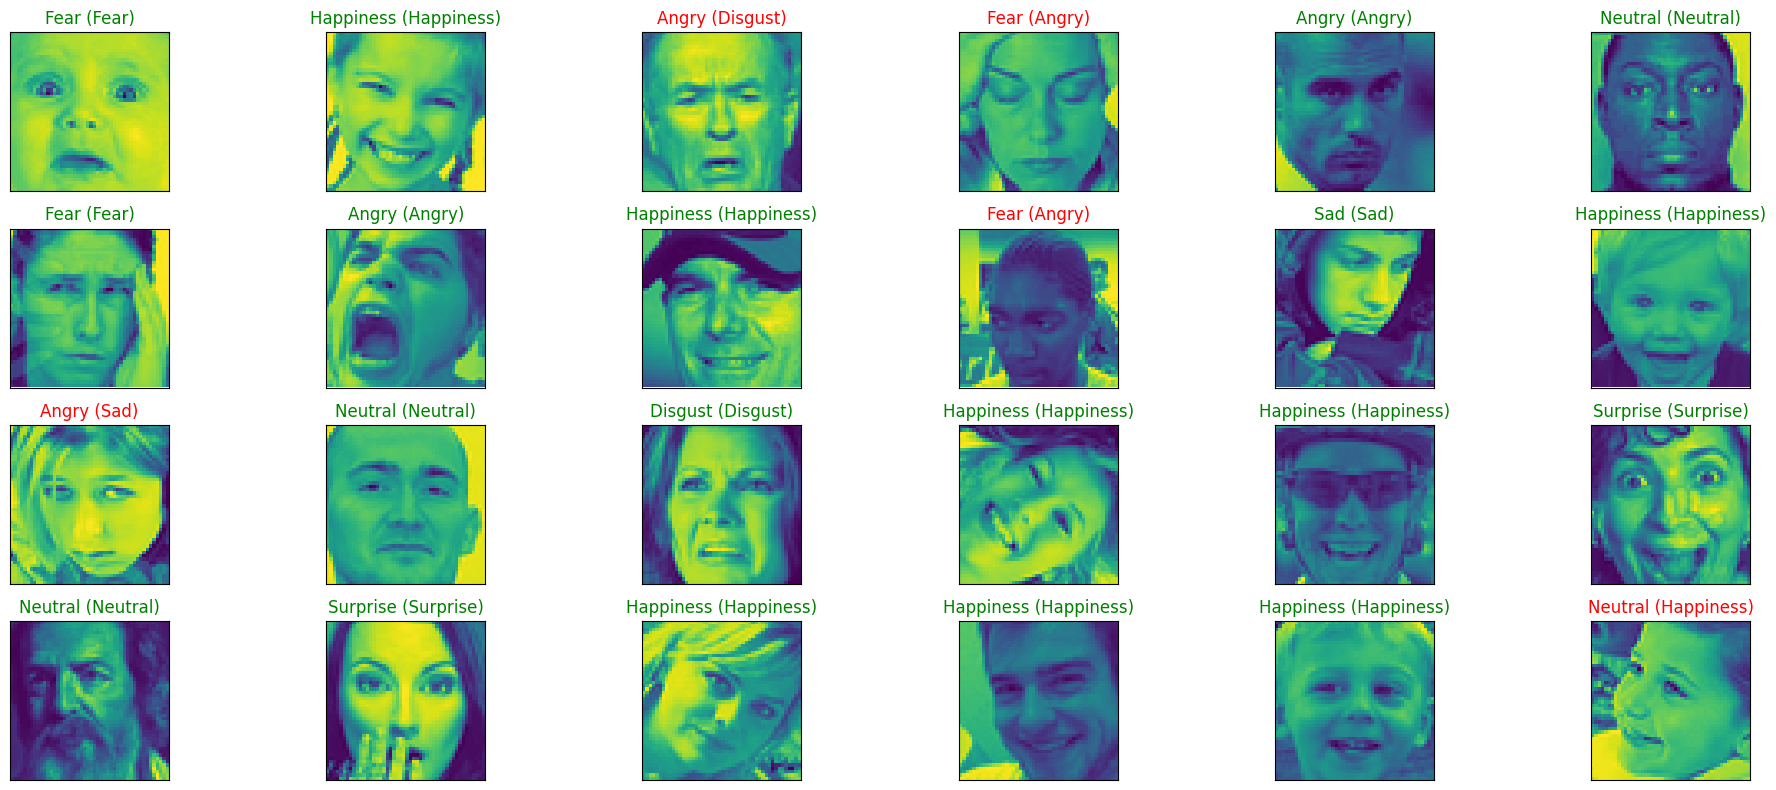

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

label_dict = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happiness', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Create a figure with a size to display 24 images
figure = plt.figure(figsize=(20, 8))

# Ensure the random indices are within the correct bounds
num_samples = x_test_reshape_bl.shape[0]

# Select 24 random indices from the test set, ensuring that the indices do not exceed the available samples
for i, index in enumerate(np.random.choice(num_samples, size=24, replace=False)):
    ax = figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_test_reshape_bl[index]))  # Display the image

    # Get the predicted and true labels
    predict_index = label_dict[y_pred_bl[index].argmax()]  # Use .argmax() if y_pred_bl contains probabilities
    true_index = label_dict[np.argmax(y_test_balanced, axis=1)[index]]

    # Set the title of each subplot, using green for correct predictions and red for incorrect
    ax.set_title("{} ({})".format(predict_index, true_index),
                 color="green" if predict_index == true_index else "red")

# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

def plot_image_and_emotion(test_image_array, test_image_label, pred_test_labels, image_number, emotions):
    """
    Function to plot the image and compare the prediction results with the true label
    Args:
        test_image_array: Array of test images (e.g., x_test_reshape_bl)
        test_image_label: Actual true labels of the test images
        pred_test_labels: Predictions (probabilities) from the model for each image
        image_number: The index of the image to visualize
        emotions: A dictionary that maps label numbers to emotion names (e.g., {0: 'Angry', 1: 'Disgust', ...})
    """

    # Create a subplot with 1 row and 2 columns (for the image and the bar plot)
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

    # Plot the test image
    axs[0].imshow(test_image_array[image_number], cmap='gray')  # Use 'gray' for grayscale images
    axs[0].set_title(f"True: {emotions[test_image_label[image_number]]}")

    # Plot the predicted probabilities as a bar plot
    bar_labels = list(emotions.values())  # Get the emotion names for the x-axis
    axs[1].bar(bar_labels, pred_test_labels[image_number], color='orange', alpha=0.7)
    axs[1].set_ylabel("Probability")
    axs[1].set_xlabel("Emotion")
    axs[1].set_title("Predicted Probabilities")
    axs[1].grid(True)

    plt.tight_layout()  # Adjust layout for better appearance
    plt.show()


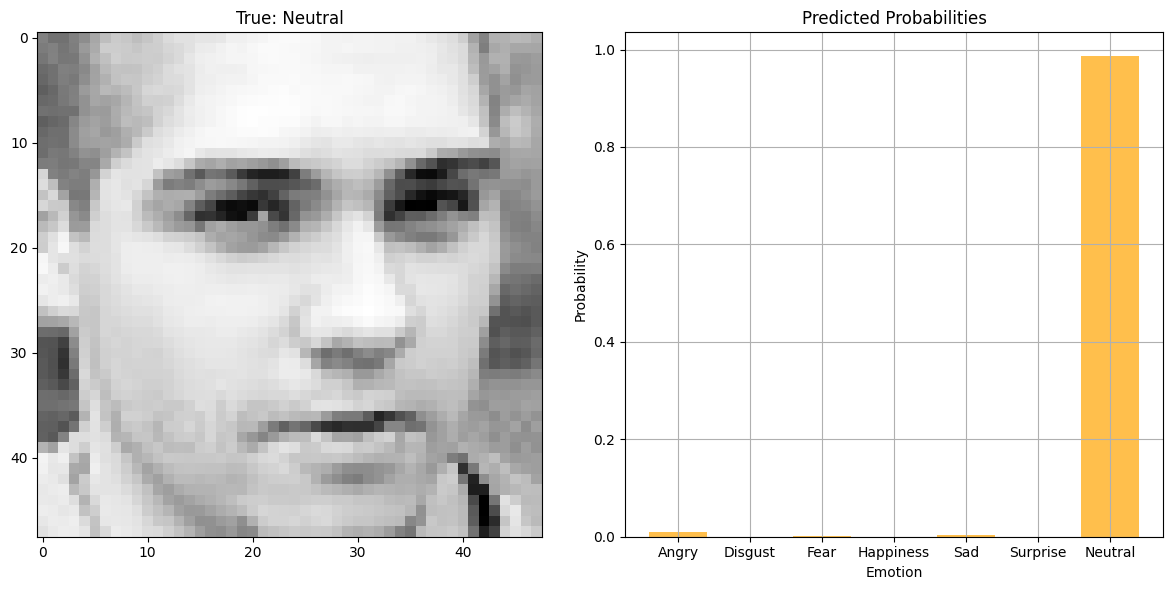

In [ ]:
plot_image_and_emotion(x_test_reshape_bl, y_test_balanced.argmax(axis=1), y_pred_bl, 66,emotions=label_dict)

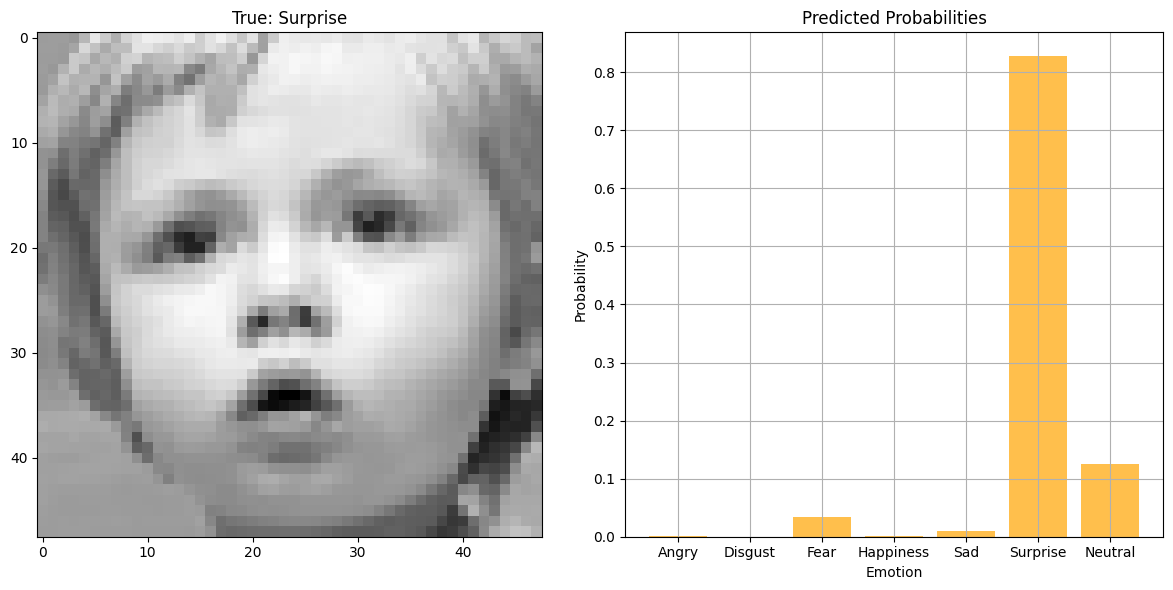

In [ ]:
plot_image_and_emotion(x_test_reshape_bl, y_test_balanced.argmax(axis=1), y_pred_bl, 123,emotions=label_dict)

In [ ]:
# Save the model to a file
model_bl3.save('emotion_recognition_model.keras')